In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Creating the data frame
dataframe = pd.read_csv("content/Zomato-data-.csv")
print(dataframe.head())

#Data cleaning and preparation [Removing the /5 in rate column]
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)

dataframe['rate'] = dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  
                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No 

In [3]:
#Getting summary of the data frame
dataframe.info()

#Checking for missing or null values
print(dataframe.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 8.2 KB
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


Text(0.5, 1.0, 'Types of restaurant')

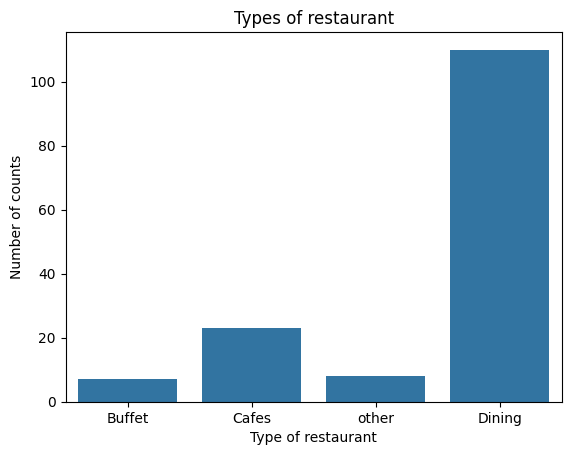

In [4]:
#Exploring restaurant types using seaborn and matlibplot
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("Type of restaurant")
plt.ylabel("Number of counts")
plt.title("Types of restaurant")

Text(0.5, 1.0, 'Number of votes that each reataurant type gets')

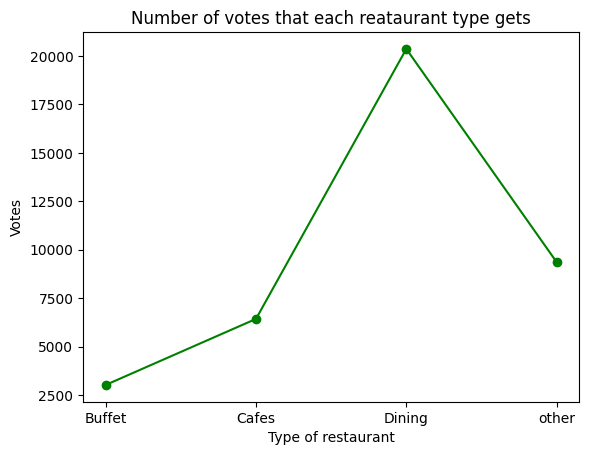

In [5]:

#Get the count of votes for each of the category
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes':grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel("Type of restaurant")
plt.ylabel("Votes")
plt.title('Number of votes that each reataurant type gets')

In [6]:
#Identify the most voted restaurant
max_votes = dataframe['votes'].max()
restaurant_max = dataframe.loc[dataframe['votes'] == max_votes, 'name']
print('Restaurant with the maximum votes: ')
print(restaurant_max)

Restaurant with the maximum votes: 
38    Empire Restaurant
Name: name, dtype: str


Text(0.5, 1.0, 'Number of restaurant that accepts online orders')

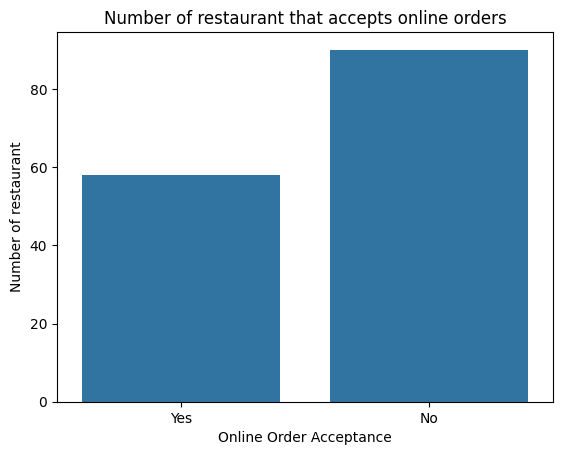

In [7]:
#How many restaurant accept online orders
sns.countplot(x=dataframe['online_order'])
plt.xlabel('Online Order Acceptance')
plt.ylabel('Number of restaurant')
plt.title('Number of restaurant that accepts online orders')

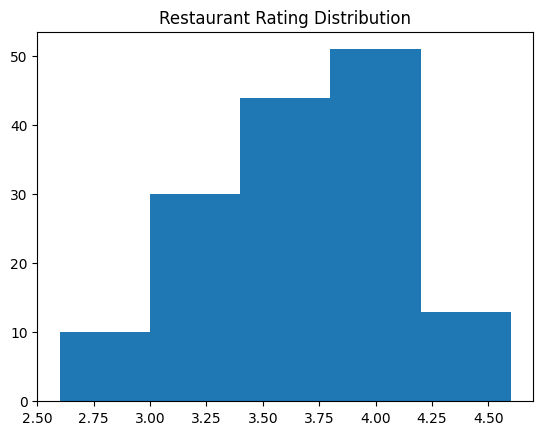

In [8]:
#Analyse Ratings of each restaurant
plt.hist(dataframe['rate'], bins=5)
plt.title('Restaurant Rating Distribution')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

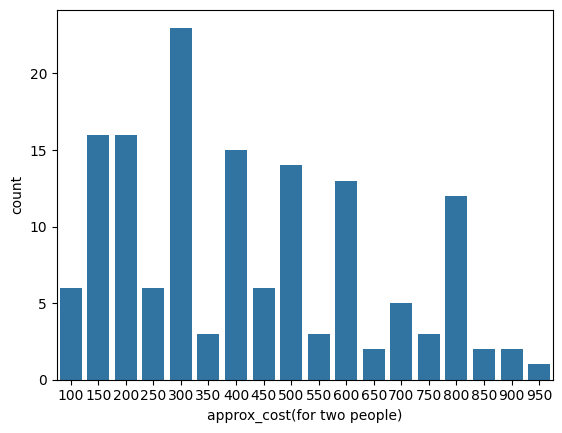

In [9]:
#Approximate Cost for Couples
couple_data = dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

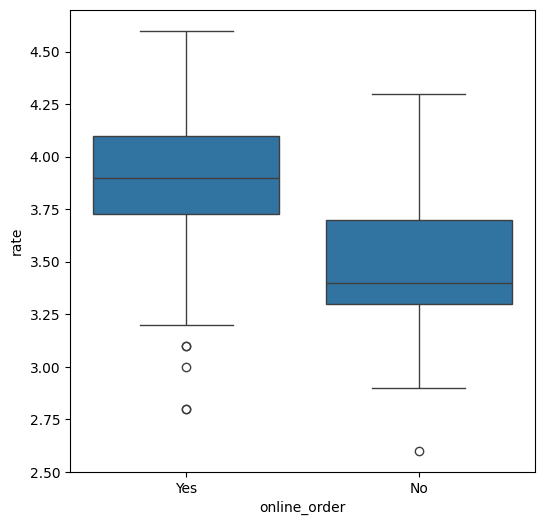

In [11]:
#Rating Comparisons - Online vs Offline Orders
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)

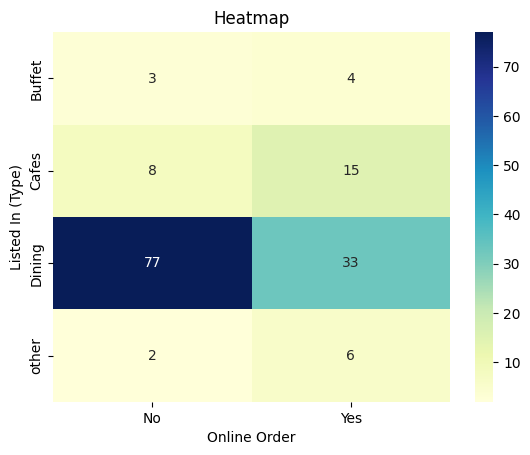

In [13]:
#Order mode preferences by restaurant type
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order',aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu',fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()